In [2]:
import yfinance as yf
import pandas as pd

In [ ]:
# Price nd volume history
ticker = yf.Ticker("AAPL")
data = ticker.history(period="90d")
print(data)

                                 Open        High         Low       Close  \
Date                                                                        
2025-09-23 00:00:00-04:00  255.632202  257.090779  253.334426  254.183594   
2025-09-24 00:00:00-04:00  254.972829  255.492329  250.796869  252.065643   
2025-09-25 00:00:00-04:00  252.964772  256.920944  251.466225  256.621216   
2025-09-26 00:00:00-04:00  253.853917  257.350528  253.534220  255.212601   
2025-09-29 00:00:00-04:00  254.313473  254.753049  252.764971  254.183594   
...                               ...         ...         ...         ...   
2026-01-26 00:00:00-05:00  251.479996  256.559998  249.800003  255.410004   
2026-01-27 00:00:00-05:00  259.170013  261.950012  258.209991  258.269989   
2026-01-28 00:00:00-05:00  257.649994  258.859985  254.509995  256.440002   
2026-01-29 00:00:00-05:00  258.000000  259.649994  254.410004  258.279999   
2026-01-30 00:00:00-05:00  255.169998  261.899994  252.179993  259.480011   

In [ ]:
# news
news = ticker.news
print(news.content)

{'id': '8a4e7b5d-784a-415e-b0b8-1a231197de16', 'content': {'id': '8a4e7b5d-784a-415e-b0b8-1a231197de16', 'contentType': 'VIDEO', 'title': 'Apple: Could the memory chip shortage raise iPhone prices?', 'description': '<p>In Apple\'s (<a target="_blank" rel="" class="link" href="https://finance.yahoo.com/quote/AAPL/" data-i13n="slk:AAPL;cpos:1;pos:1">AAPL</a>) earnings call, CEO Tim Cook warned that <a target="_blank" class="link" href="https://finance.yahoo.com/video/apple-ceo-tim-cook-talks-memory-shortages-other-supply-constraints-230214568.html" data-i13n="cpos:2;pos:1">the memory chip shortage</a> could have an impact on the iPhone maker\'s gross margin in its fiscal second quarter.</p><p>Maxim Group managing director and senior consumer internet analyst Tom Forte — who <a target="_blank" class="link" href="https://finance.yahoo.com/video/apple-why-this-analyst-upgraded-the-stock-despite-margin-worries-170000051.html" data-i13n="cpos:3;pos:1">upgraded Apple stock</a> to a Buy rating 

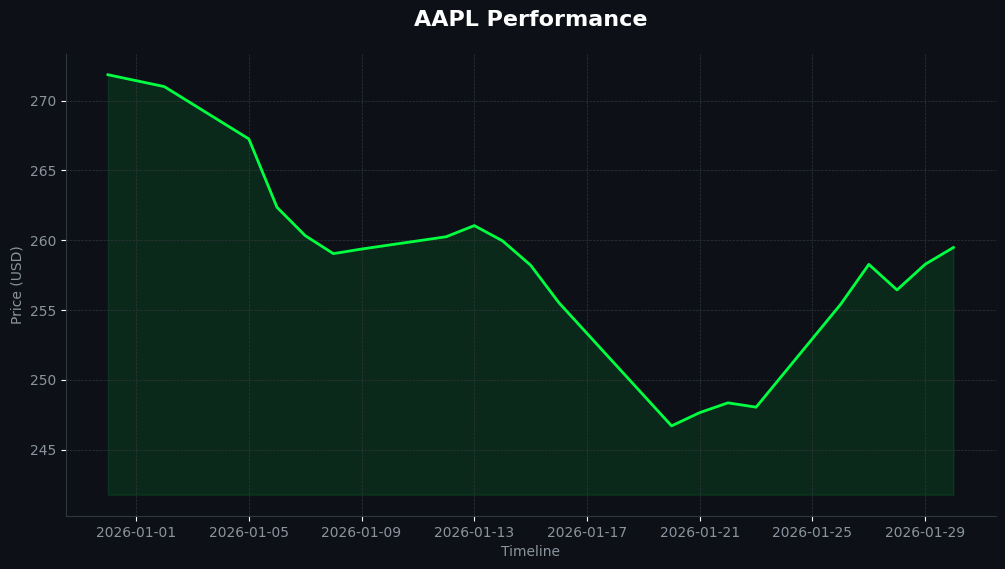

{'data': [{'Date': '2025-12-31 00:00:00', 'Open': 273.05999755859375, 'High': 273.67999267578125, 'Low': 271.75, 'Close': 271.8599853515625, 'Volume': 27293600, 'Dividends': 0.0, 'Stock Splits': 0.0}, {'Date': '2026-01-02 00:00:00', 'Open': 272.260009765625, 'High': 277.8399963378906, 'Low': 269.0, 'Close': 271.010009765625, 'Volume': 37838100, 'Dividends': 0.0, 'Stock Splits': 0.0}, {'Date': '2026-01-05 00:00:00', 'Open': 270.6400146484375, 'High': 271.510009765625, 'Low': 266.1400146484375, 'Close': 267.260009765625, 'Volume': 45647200, 'Dividends': 0.0, 'Stock Splits': 0.0}, {'Date': '2026-01-06 00:00:00', 'Open': 267.0, 'High': 267.54998779296875, 'Low': 262.1199951171875, 'Close': 262.3599853515625, 'Volume': 52352100, 'Dividends': 0.0, 'Stock Splits': 0.0}, {'Date': '2026-01-07 00:00:00', 'Open': 263.20001220703125, 'High': 263.67999267578125, 'Low': 259.80999755859375, 'Close': 260.3299865722656, 'Volume': 48309800, 'Dividends': 0.0, 'Stock Splits': 0.0}, {'Date': '2026-01-08 00
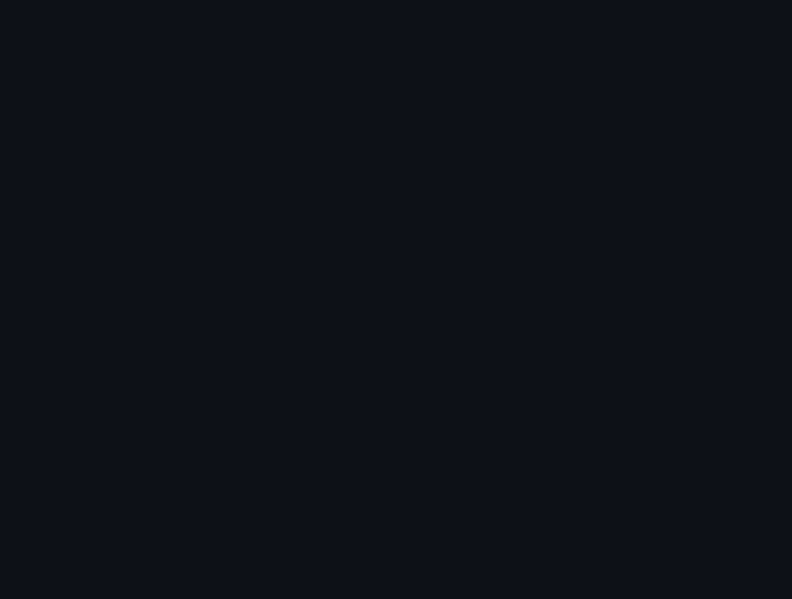

<Figure size 640x480 with 0 Axes>

In [7]:
import yfinance as yf
import matplotlib.pyplot as plt
import io
import base64

def get_historical_data(ticker_symbol, interval, period="3mo"):
    ticker = yf.Ticker(ticker_symbol)
    hist = ticker.history(period=period, interval=interval)
    
    if hist.empty:
        return {"data": [], "graph": None}

    # 1. Prepare Data
    hist_json = hist.reset_index()
    hist_json['Date'] = hist_json['Date'].dt.strftime('%Y-%m-%d %H:%M:%S')
    data_records = hist_json.to_dict(orient='records')

    # 2. Modern Dark UI Styling
    plt.style.use('dark_background') # Sets the base dark theme
    fig, ax = plt.subplots(figsize=(12, 6), facecolor='#0D1117') # Match GitHub dark mode color
    ax.set_facecolor('#0D1117')

    # Plotting the Close price with a vibrant green
    ax.plot(hist.index, hist['Close'], color='#00ff41', linewidth=2, label='Close Price')
    
    # Adding a gradient-like fill underneath the line
    ax.fill_between(hist.index, hist['Close'], min(hist['Close']) * 0.98, 
                    color='#00ff41', alpha=0.1)

    # Customizing Grid and Borders
    ax.grid(color='#30363d', linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#30363d')
    ax.spines['bottom'].set_color('#30363d')

    # Titles and Labels
    plt.title(f"{ticker_symbol} Performance", color='white', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel("Price (USD)", color='#8b949e')
    plt.xlabel("Timeline", color='#8b949e')
    plt.xticks(color='#8b949e')
    plt.yticks(color='#8b949e')

    plt.show()

    # 3. Buffer Logic
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', dpi=120, facecolor=fig.get_facecolor())
    plt.close(fig)
    buf.seek(0)
    
    image_base64 = base64.b64encode(buf.read()).decode('utf-8')
    
    return {
        "data": data_records,
        "graph": f"data:image/png;base64,{image_base64}"
    }
# Example usage
result = get_historical_data("AAPL", "1d", "1mo")
print(result)